In [10]:
!pip install yfinance
!pip install pandas
!pip install pandas_datareader
from pandas_datareader import data as pdr
!pip install datetime
!pip install numpy


   ---------------------------------------- 0/2 [zope.interface]
   -------------------- ------------------- 1/2 [datetime]
   ---------------------------------------- 2/2 [datetime]



In [11]:
import yfinance as yf
import pandas as pd
from pandas_datareader import data as pdr
import datetime as dt
import numpy as np

In [15]:
endDate =dt.datetime.now()

startDate = endDate - dt.timedelta(days=365*5) # we are going back 5 years from today
endDate, startDate

(datetime.datetime(2026, 10, 3, 17, 19, 12, 965382),
 datetime.datetime(2021, 10, 4, 17, 19, 12, 965382))

In [21]:
stocks= ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'V', 'JNJ', 'SPY', 'QQQ']

df = yf.download(stocks, start=startDate, end=endDate)


[*********************100%***********************]  12 of 12 completed


In [19]:
df.head()



Price            Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2021-10-04  135.713120  159.488998  132.399628  138.470016  147.317749   
2021-10-05  137.634598  161.050003  134.740829  138.783066  149.723465   
2021-10-06  138.502701  163.100494  136.268326  139.070084  150.043030   
2021-10-07  139.760925  165.121506  137.912674  140.313690  150.992889   
2021-10-08  139.380569  164.431000  138.467896  139.957138  151.108353   

Price                                                                  ...  \
Ticker            META        MSFT       NVDA         QQQ         SPY  ...   
Date                                                                   ...   
2021-10-04  323.135162  271.708405  19.645472  342.236694  400.908051  ...   
2021-10-05  329.801270  277.130829  20.361317  346.856537  405.079498  ...   
2021-10-06  330.474854  281.305603  20.609224  349.079102  406.763062  ...   
2021-10-07  326.096741  282.975586  20.982576  352.281921  410.279816  ...   
2021-10-08  326.918823  282.975586  20.739651  350.525238  409.531555  ...   

Price         Volume                                                    \
Ticker         GOOGL      JNJ       JPM      META      MSFT       NVDA   
Date                                                                     
2021-10-04  51202000  8620700  14120000  42885000  31350700  345635000   
2021-10-05  32404000  5129000  12292900  35377900  24993000  279282000   
2021-10-06  24364000  7312600   8692600  26443000  28002600  297202000   
2021-10-07  25110000  5309200  10195400  28307500  20430500  256919000   
2021-10-08  26526000  4343200   8190100  15946100  17685700  151258000   

Price                                                
Ticker           QQQ        SPY      TSLA         V  
Date                                                 
2021-10-04  76766000  128570000  91449900  10283400  
2021-10-05  47232900   90682500  55297800   5814000  
2021-10-06  56806500  113032200  43898400   5420900  
2021-10-07  39411200   72437500  57587400   6561900  
2021-10-08  41822300   74557400  50215800   3735200  

[5 rows x 60 columns]

In [25]:
adj_close_price = df['Close']
adj_close_price.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,QQQ,SPY,TSLA,V
Date,,,,,,,,,,,,
2021-10-04,135.713150,159.488998,132.399612,138.470001,147.317734,323.135132,271.708405,19.645472,342.236755,400.908051,260.510010,216.375610
2021-10-05,137.634583,161.050003,134.740845,138.783112,149.723480,329.801300,277.130829,20.361320,346.856567,405.079498,260.196655,215.942383
2021-10-06,138.502716,163.100494,136.268311,139.070099,150.043030,330.474823,281.305634,20.609221,349.079193,406.763062,260.916656,218.089508
2021-10-07,139.760925,165.121506,137.912689,140.313690,150.992920,326.096741,282.975616,20.982584,352.281982,410.279755,264.536682,221.979309
2021-10-08,139.380508,164.431000,138.467865,139.957169,151.108292,326.918823,282.975616,20.739651,350.525269,409.531403,261.829987,221.709702


In [ ]:
log_returns = np.log(adj_close_price / adj_close_price.shift(1))
log_returns.head() #calculate of daily returns

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,QQQ,SPY,TSLA,V
Date,,,,,,,,,,,,
2021-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-10-05,0.014059,0.009740,0.017529,0.002259,0.016198,0.020420,0.019760,0.035790,0.013409,0.010351,-0.001204,-0.002004
2021-10-06,0.006288,0.012652,0.011273,0.002066,0.002132,0.002040,0.014952,0.012102,0.006387,0.004148,0.002763,0.009894
2021-10-07,0.009043,0.012315,0.011995,0.008902,0.006311,-0.013336,0.005919,0.017954,0.009133,0.008608,0.013779,0.017679
2021-10-08,-0.002726,-0.004191,0.004017,-0.002544,0.000764,0.002518,0.000000,-0.011645,-0.004999,-0.001826,-0.010285,-0.001215


In [29]:
cumulative_log_returns = log_returns.cumsum()
cumulative_log_returns.head() #calculate of cumulative returns

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,QQQ,SPY,TSLA,V
Date,,,,,,,,,,,,
2021-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-10-05,0.014059,0.009740,0.017529,0.002259,0.016198,0.020420,0.019760,0.035790,0.013409,0.010351,-0.001204,-0.002004
2021-10-06,0.020346,0.022392,0.028801,0.004324,0.018330,0.022460,0.034712,0.047892,0.019796,0.014499,0.001560,0.007890
2021-10-07,0.029390,0.034707,0.040796,0.013227,0.024641,0.009123,0.040631,0.065846,0.028929,0.023107,0.015339,0.025568
2021-10-08,0.026664,0.030516,0.044814,0.010683,0.025405,0.011641,0.040631,0.054201,0.023930,0.021281,0.005054,0.024353


<Axes: title={'center': 'Cumulative Returns'}, xlabel='Date'>

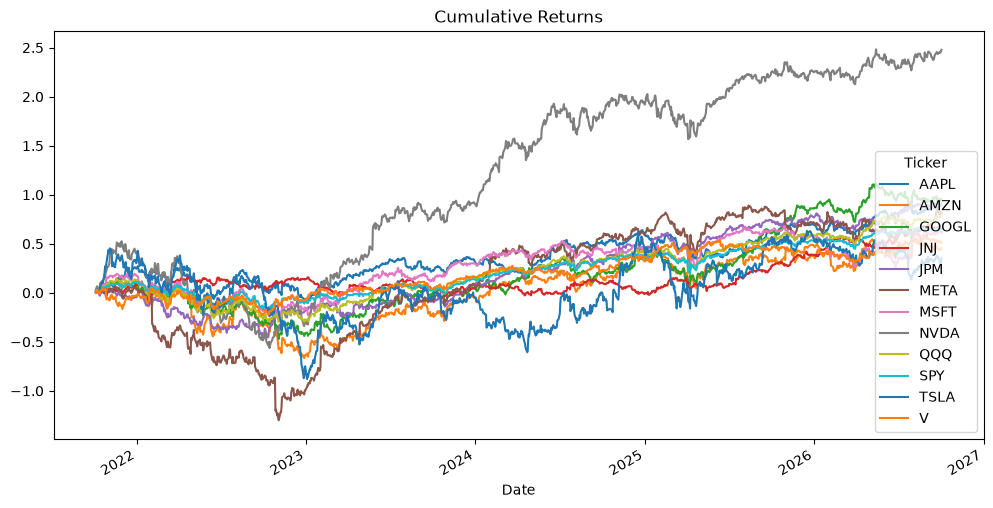

In [30]:
cumulative_log_returns.plot(title='Cumulative Returns', figsize=(12, 6))

In [37]:
import math
from scipy.stats import norm

#Define the Variable
S= 45 #Underlaying Price
K= 40 #Strike Price
r= 0.1 #Risk-free Rate
sigma= 0.2 #Volatility
T= 0.5 #Time to Maturity

d1=(math.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*math.sqrt(T))
d2=d1-sigma*math.sqrt(T)

#Calculate the Call Option Price
call_price = S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

#Calculate the Put Option Price
put_price = K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

print ('The value of d1 is :', round(d1, 4))
print ('The value of d2 is :', round(d2, 4))
print ('The call option price is :$', round(call_price, 4))
print ('The put option price is :$', round(put_price, 4))


The value of d1 is : 1.2571
The value of d2 is : 1.1157
The call option price is :$ 7.2878
The put option price is :$ 0.337


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                   SPY        AAPL        MSFT       GOOGL        AMZN
Date                                                                  
2006-10-09   93.721268    2.232156   19.418289   10.634541    1.669000
2006-10-10   93.846138    2.207629   19.397282   10.576285    1.631000
2006-10-11   93.735130    2.190282   19.292200   10.572569    1.645500
2006-10-12   94.546867    2.250999   19.768545   10.595870    1.677500
2006-10-13   94.789658    2.243820   19.873631   10.592398    1.666000
...                ...         ...         ...         ...         ...
2026-09-28  765.609985  338.399994  509.220001  342.750000  246.149994
2026-09-29  764.200012  329.399994  508.959991  340.920013  246.669998
2026-09-30  762.630005  333.019989  512.900024  344.079987  249.149994
2026-10-01  763.989990  330.320007  512.799988  338.239990  248.229996
2026-10-02  769.640015  333.690002  517.530029  343.500000  251.520004

[5027 rows x 5 columns]
                 SPY      AAPL      MSFT     GOOGL  

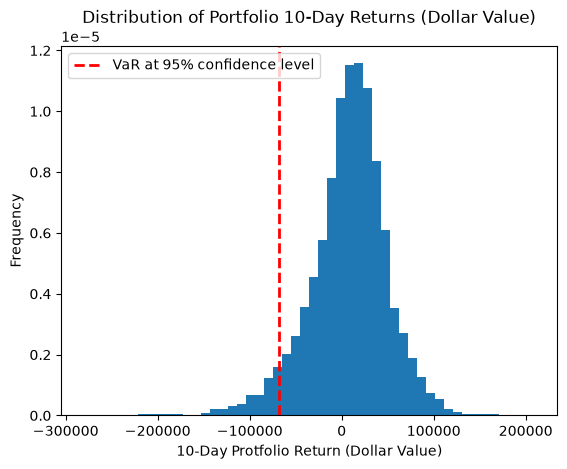

In [47]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats

years = 20
endDate= dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*20)
tickers =['SPY', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', ]
adj_close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start=startDate, end=endDate)
    adj_close_df[ticker] = data['Close']

print(adj_close_df)
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

#create an equally weighted portfolio
portfolio_value=1000000
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
historical_returns= (log_returns *weights).sum(axis=1)
print(historical_returns)
#find the X-day historical returns
days = 10
range_returns= historical_returns.rolling(window=days).sum()
range_returns = range_returns.dropna()
print(range_returns)

#specify a confidence level  and calculate the VaR using historical method

confidence_interval = 0.95
VaR = -np.percentile(range_returns, 100 - (confidence_interval * 100))*portfolio_value
print(VaR)

#plot the results of the historical returns

return_window=days
range_returns = historical_returns.rolling(window=return_window).sum()
range_returns = range_returns.dropna()

range_returns_dollar = range_returns * portfolio_value

plt.hist(range_returns_dollar.dropna(), bins=50, density=True)
plt.xlabel(f'{return_window}-Day Protfolio Return (Dollar Value)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {return_window}-Day Returns (Dollar Value)')
plt.axvline(-VaR, color='r', linestyle='dashed', linewidth=2, label=f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()




In [ ]:
#VaR using parametric method

#Step is same like historical method until we try to define the number of days 
days= 10
historical_x_day_returns=historical_returns.rolling(window=days).sum()

#create a covariance matrix for all the securities in the portfolio
cov_matrix = log_returns.cov() * 252 # we annualized it

portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights) 

#set confidence level
confidence_level = [0.9, 0.95, 0.99]

from scipy.stats import norm
VaRs = []

for cl in confidence_level:
    VaR = portfolio_value * portfolio_std_dev * norm.ppf(cl)*np.sqrt(days/252)
    VaRs.append(VaR)

print(f'{'Confidence Level':<20}{'VaR ($)':<20}')
print('-'*40)

#print each confidence level and its corresponding VaR
for cl, VaR in zip(confidence_level, VaRs):
    print(f'{cl*100:>6.0f}%: {'':<8} ${VaR:>10,.2f}')

Confidence Level    VaR ($)             
----------------------------------------
    90%:          $ 60,679.06
    95%:          $ 77,880.73
    99%:          $110,148.20


-70095.18430881725


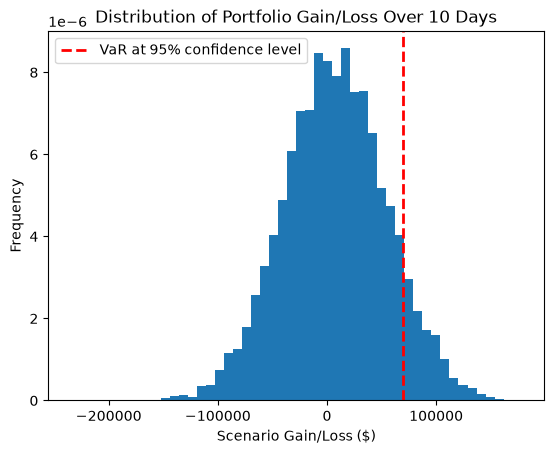

In [59]:
#VaR  Monte Carlo Method

#step is the same like historical method until we try to define the equally weighted number of portfolio

#define function that calculate our portfolio expected return

def expected_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights)

#create a function that calculate the portfolio standard deviation

def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)
#create a covariance matrix for all the securities in the portfolio
cov_matrix = log_returns.cov()
#create an equally weighted portfolio
portfolio_value=1000000
weights = np.array([1/len(tickers)]*len(tickers))

portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std_dev = standard_deviation(weights, cov_matrix)

#create a function that gives a random z-score based on normal distribution
def random_z_score():
    return np.random.normal(0, 1)

#create a function that calculate a scenario gain or loss
days = 10
def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days):
    return portfolio_value *  portfolio_expected_return * days + portfolio_value * portfolio_std_dev * z_score * np.sqrt(days)

# run 10000 simulations
simulations = 10000
scenarioReturn=[]
for i in range(simulations):
    z_score = random_z_score()
    scenarioReturn.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))

#specify confidence interval and calculate the VaR
confidence_interval = 0.95
var = np.percentile(scenarioReturn, 100*(1-confidence_interval))
print(var)

#plot the results of the Monte Carlo simulations
plt.hist(scenarioReturn, bins=50, density=True)
plt.xlabel('Scenario Gain/Loss ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio Gain/Loss Over {days} Days')
plt.axvline(-var, color='r', linestyle='dashed', linewidth=2, label=f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()


